# Ultraviolet Spectral Analysis Using Astropy

#### Analyzing ultraviolet spectral data by extracting, cleaning, and visualizing flux as a function of wavelength to identify trends and potential spectral features.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from scipy.ndimage import gaussian_filter1d

#### Load FITS file, inspect data

Using data from the International Ultraviolet Explorer (IUE) of a region in the galaxy NGC 4151 that focuses on ultraviolet (UV) spectral observations.

In [3]:
# Load FITS file
hdul = fits.open('IUE_LWP.fits')
hdul.info()
# NGC 4151 (galaxy w/ active nucleus)

Filename: IUE_LWP.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     354   ()      
  1  MELO          1 BinTableHDU     37   1R x 9C   [5A, 1I, 1E, 1E, 640E, 640E, 640E, 640I, 640E]   


In [4]:
# Access data
data = hdul[1].data

# Inspect columns
print(data.columns)

# Assign variables
wavelength_start = data[0]['WAVELENGTH'] # UV region of electromagnetic spectrum (starting point)
delta_w = data[0]['DELTAW'] # Step size for wavelength
flux = data[0]['FLUX'] # Amount of light energy received at each wavelength
quality = data[0]['QUALITY'] # Quality flags for data

ColDefs(
    name = 'APERTURE'; format = '5A'
    name = 'NPOINTS'; format = '1I'
    name = 'WAVELENGTH'; format = '1E'; unit = 'ANGSTROM'
    name = 'DELTAW'; format = '1E'; unit = 'ANGSTROM'
    name = 'NET'; format = '640E'; unit = 'FN'
    name = 'BACKGROUND'; format = '640E'; unit = 'FN'
    name = 'SIGMA'; format = '640E'; unit = 'ERG/CM2/S/A'
    name = 'QUALITY'; format = '640I'
    name = 'FLUX'; format = '640E'; unit = 'ERG/CM2/S/A'
)


#### Create wavelength array and select quality data

In [5]:
# Create wavelength array with starting point and step size
#n_points = len(flux)
n_points = data[0]['NPOINTS']
wavelength = wavelength_start + np.arange(n_points) * delta_w 

In [6]:
# Filter bad data
mask = (quality == 0)

wavelength_clean = wavelength[mask]
flux_clean = flux[mask]

#### Plot spectrum

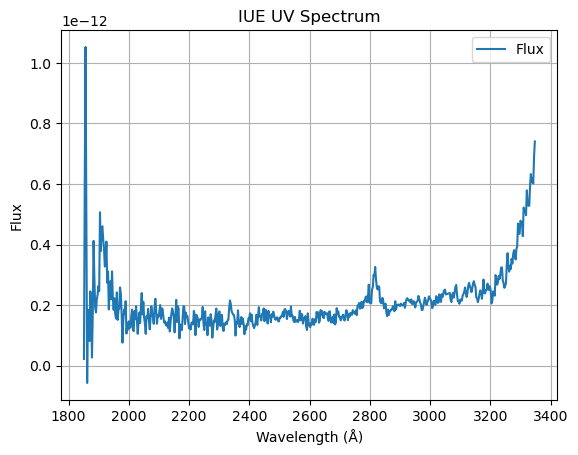

In [7]:
# Plot spectrum
plt.figure()
plt.plot(wavelength_clean, flux_clean, label='Flux')
plt.xlabel('Wavelength (Å)')
plt.ylabel('Flux')
plt.title('IUE UV Spectrum')
plt.legend()
plt.grid(True)
plt.show()

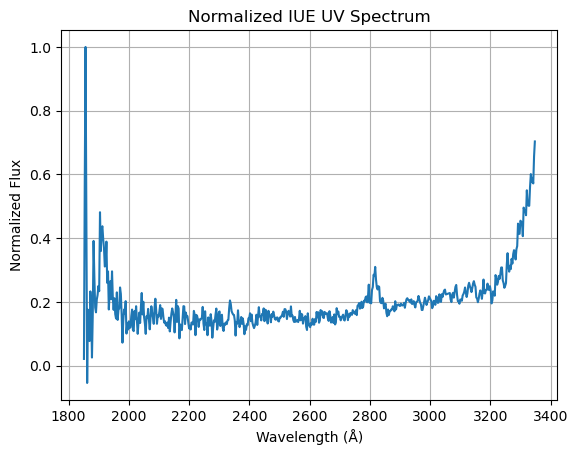

In [8]:
# Normalize spectrum
normalized_flux = flux_clean / np.max(flux_clean)

plt.figure()
plt.plot(wavelength_clean, normalized_flux)
plt.xlabel('Wavelength (Å)')
plt.ylabel('Normalized Flux')
plt.title('Normalized IUE UV Spectrum')
plt.grid(True)
plt.show()

How much UV light a region in NGC 4151 emits at different wavelengths.

#### Ignore noise and smooth plot

Peak at index: 363


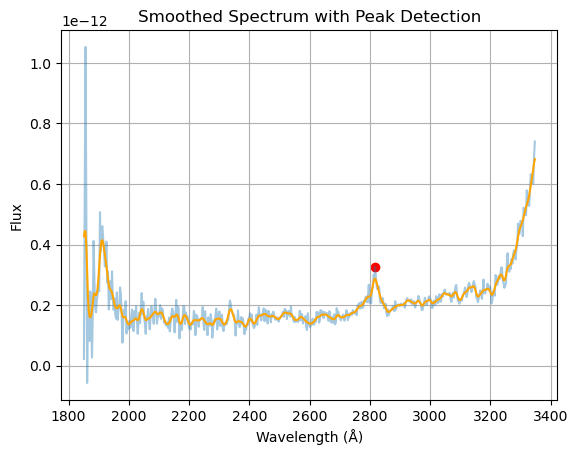

In [9]:
# Ignore noisy edges (first/last ~50 pts)
start = 50
end = -50
relative_peak_index = np.argmax(flux_clean[start:end])
peak_index = relative_peak_index + start
print('Peak at index:', peak_index)

# Smoother plot
flux_smooth = gaussian_filter1d(flux_clean, sigma=2)

plt.figure()
plt.plot(wavelength_clean, flux_clean, alpha=0.4, label='Raw')
plt.plot(wavelength_clean, flux_smooth, label='Smoothed', color='orange')

plt.scatter(wavelength_clean[peak_index], flux_clean[peak_index], color='red')

plt.xlabel('Wavelength (Å)')
plt.ylabel('Flux')
plt.title('Smoothed Spectrum with Peak Detection')
plt.grid(True)
plt.show()

### Conclusion

The processed ultraviolet spectrum shows a relatively stable flux between 2000-2700 Å, with increased noise at shorter wavelengths. A small feature appears near 2800 Å, and flux increases at longer wavelengths. These patterns are consistent with observational spectral data and may indicate underlying physical processes in the observed region of NGC 4151.

The large fluctuations and prominent spike around 1800 Å likely indicate a lower signal-to-noise region or instrument sensitivity limitations. In contrast, the region between 2000-2700 Å shows less variation and is likely where the signal is most reliable, representing continuum emission. The small feature around 2800 Å may correspond to an emission or absorption feature associated with atomic transitions. The increasing trend between 3000-3400 Å could reflect changes in emission intensity or the slope of the underlying continuum, potentially indicating physical processes in the observed region.

Peak detection was refined to exclude noisy edge regions of the spectrum, ensuring that identified features correspond to meaningful spectral structure rather than observational artifacts.

These interpretations are based on processed and quality-filtered spectral data, demonstrating how FITS-based observational data can be cleaned and analyzed using Python and Astropy.

In [10]:
hdul.close()